# **SUPERVISED LEARNING**

## **Learning a class from examples**

> Let us say we want **to learn the class**, $C$, of a **sedan car**. We start with a **set of examples** of various cars and conduct a survey where people examine these cars and **label them**.

> Those cars that participants believe fit the characteristics of a sedan are marked as **positive examples**, while all other cars are marked as **negative examples**.

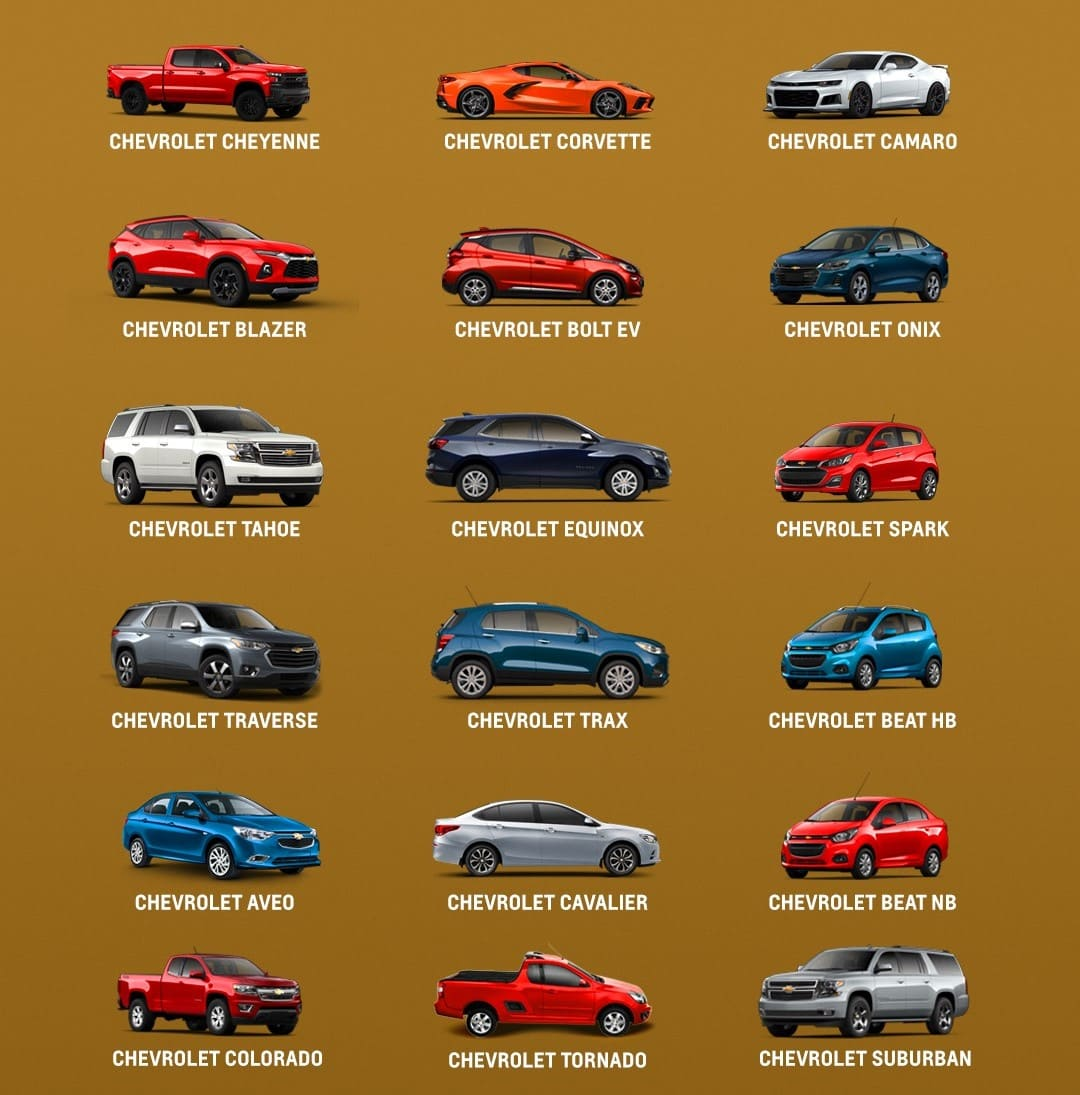



>The goal of **class learning** is to derive a **description** that **applies** to all **positive examples** and **excludes** all **negative examples**.

> With this description, we can **make predictions**: when presented with a new car, we can determine whether it is a sedan based on the learned description.

> After some discussions with experts in the field, let us say that we reach the conclusion that among all features a car may have, the **features that separate** a sedan car from other cars are the **price** and **engine power**. These two attributes are the **inputs** to the class recognizer.

> Note that when we decide on this particular **input representation**, we are ignoring various other attributes as irrelevant.

> Let us denote price as the first input attribute $x_1$ (e.g., in U.S. dollars) and size as the second attribute $x_2$ e.g., the car's length in meters). Thus we represent each car using the **feature vector**
$$\textbf{x} = \left[\begin{matrix} x_1 \\ x_2 \end{matrix} \right]$$
> and its **label** denotes its type
$$ r = \begin{cases}1 \qquad \text{if $x$ is a positive example} \\ 0 \qquad \text{if $x$ is a negative example} \end{cases}$$

>  Each car is represented by such an ordered pair $(\textbf{x}, r)$ and the **training set** contains $N$ such examples
$$\textbf{X} = \{\textbf{x}^i, r^i\}^N_{i=1}$$
where $i$ indexes different examples in the set; it does not represent time or any such order.

> Our training data can now be plotted in the two-dimensional $(x_1, x_2)$ space where each instance $i$ is a data point at coordinates
 $$(x^i_1, x^i_2)$$
> and its class, namely, positive versus negative, is given by $r^i$.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

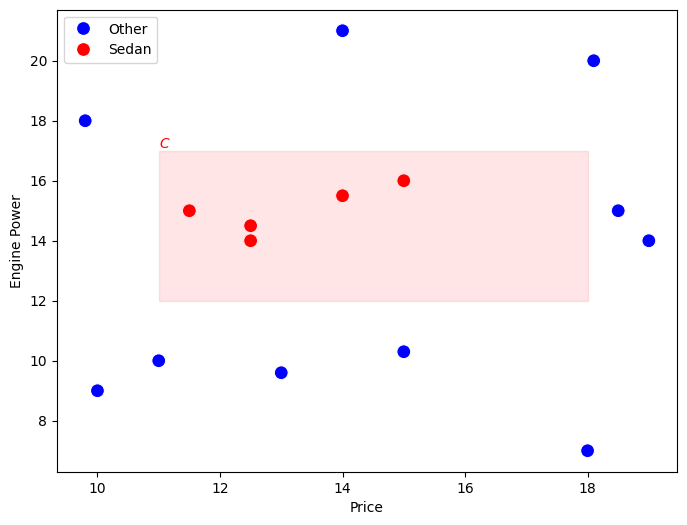

In [4]:
data = {
    "Price": [10, 11, 13, 15, 18, 9.8, 11.5, 12.5, 15, 12.5, 14, 14, 18.1, 18.5, 19],
    "Engine Power": [9, 10, 9.6, 10.3, 7, 18, 15, 14, 16, 14.5, 15.5, 21, 20, 15, 14],
     "Class": ["O", "O", "O", "O", "O", "O", "S", "S", "S", "S", "S", "O", "O", "O", "O"]
}
df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=data, x="Price", y="Engine Power", hue="Class",
                palette=['blue', 'red'], s=100)
handles, labels  =  ax.get_legend_handles_labels()
ax.legend(handles, ['Other', 'Sedan'])
ax.add_patch(
    plt.Rectangle((11, 12), 7, 5,   # Alto
        fill=True, alpha=0.1, color="red"
    )
)
ax.text(11, 17.1, "$C$", color="red")
plt.xlabel("Price")
plt.ylabel("Engine Power")
plt.show()

> Suppose we propose a **rule to classify** cars based on a range of both attributes,
$$\mathscr{H}: (p_1 \leq \text{price} \leq p2) \ \land (e_1 \leq \text{engine power} \leq e_2)$$
for suitable values of $p_1, \ p_2, \ e_1, \ e_2$ (**parameters**).
That is, we assume that $C$ is a rectangle in the engine power-price space.

> The inequality $\mathscr{H}$ is the **hypothesis class** from which we believe $C$ is drawn, namely, the set of rectangles. The **learning algorithm** then finds the **particular hypothesis** $h\in \mathscr{H}$, to approximate $C$ as closely as possible.

> Though we define the hypothesis class, the values of the **parameters are not known**; that is, though we choose $\mathscr{H}$, we do not know which particular $h\in \mathscr{H}$ is equal, or closest, to $C$. But once we restrict our attention to this hypothesis class, learning the class reduces to the easier
problem of finding the four parameters that define $h$.

> The aim is to find $h\in \mathscr{H}$ that is as similar as possible to $C$. Let us say the hypothesis $h$ makes a **prediction** for an **instance** $\textbf{x}$ such that
$$h(\textbf{x}) = \begin{cases}1 \ \text{if $h$ classifies $\textbf{x}$ as a positive example}\\ 0 \ \text{if $h$ classifies $\textbf{x}$ as a negative example} \end{cases}$$

> In real life we do not know $C(\textbf{x})$, so **we cannot evaluate** how well $h(\textbf{x})$ matches $C(\textbf{x})$.

> What we have is the **training set** $\textbf{X}$, which is a small subset of the set of all possible $\textbf{x}$.

> The **empirical error** is the **proportion (sic, quantity) of training instances** where **predictions** of $h$ **do not match** the **required values** given in $\textbf{X}$. The error of hypothesis $h$ given the training set $\textbf{X}$ is
$$\mathbb{E}(h|\textbf{X}) = \sum_{i=1}^N 1_\left(h(\textbf{x}^i) \neq r^i\right)$$
where $1_(a \neq b)$ is 1 if a $a\neq b$ and is 0 if $a = b$.

> In our example, the hypothesis class $\mathscr{H}$ is the set of all possible rectangles. Each quadruple $(p_1^h, p_2^h, e_1^h, e_2^h)$ defines one hypothesis, $h$, from $\mathscr{H}$, and we need to choose the best one, or in other words, we need to find the values of these four parameters **given the training set**, to include all the positive examples and none of the negative examples.

> There are infinitely many such $h$ for which this is satisfied, namely, for which the error, $E$, is 0, but given a future example, different candidate hypotheses may make different predictions.

> This is the problem of **generalization**, that is, how well our
hypothesis will **correctly classify future examples** that are not part of the training set.

>> One possibility is to find the most **specific hypothesis**, $S$, that is the
tightest rectangle that includes all the positive examples and none of the negative examples. Note that the actual class $C$ may be larger than $S$ but is most general never smaller.

>> The most **general hypothesis**, $G$, is the largest rectangle we
can draw that includes all the positive examples and none of the negative examples.

> Any $h \in \mathscr{H}$ between $S$ and $G$ is a valid hypothesis with no error, said to be **consistent** with the training set, and such $h$ make
up the **version space**. Given another training set, $S$, $G$, version space, the parameters and thus the learned hypothesis, $h$, can be different.

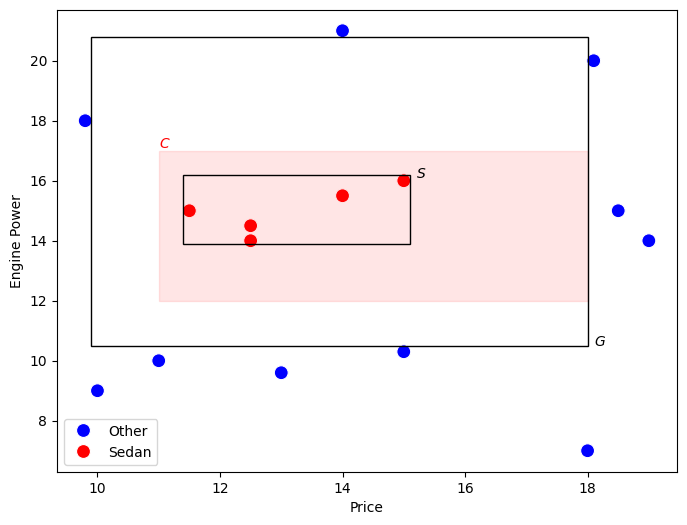

In [5]:
ax.add_patch(
    plt.Rectangle((11.4, 13.9), 3.7, 2.3, fill=False,  edgecolor="black")
)
ax.text(15.2, 16.1, "$S$")
ax.add_patch(
    plt.Rectangle((9.9, 10.5), 8.1, 10.3, fill=False, edgecolor="black")
)
ax.text(18.1, 10.5, "$G$")
fig

## **Learning Multiple Classes**

> In our example of learning a sedan car, we have positive examples belonging to the class sedan car and the negative examples belonging to all other cars. This is a **two-class problem**.

> In the general case, we have $K$ classes denoted as $C_l, \  l= 1,\ldots,K$, and an input instance belongs **to one and exactly one** of them.

> The training set is now of the form
$$\textbf{X} =\left\{\textbf{x}^i, r^i\right\}^N_{i=1}$$
where $r$ has $K$ dimensions and
$$r_l^i = \begin{cases} 1 \quad \text{if} \ \textbf{x}^i\in C_l\\ 0 \quad \ \text{if} \  \textbf{x}^i\in C_j, \ j\neq l \end{cases}$$

> In machine learning for **classification**, we would like **to learn the boundary separating** the instances of one class from the instances of all other classes.

> Thus we view a **$K$-class classification problem** as $K$ two-class problems. The training examples belonging to $C_l$ are the positive instances
of hypothesis $h_l$ and the examples of all other classes are the negative instances of $h_l$.

> Thus in a **$K$-class problem**, we have **$K$ hypotheses**
to learn such that
$$h_l(\textbf{x}^i) = \begin{cases} 1 \quad \text{if} \ \textbf{x}^i\in C_l\\ 0 \quad \ \text{if} \  \textbf{x}^i\in C_j, \ j\neq l \end{cases}$$

> The **total empirical error** takes a sum over the predictions for all classes over all instances:
$$\mathbb{E}\left(\{h_l\}_{l=1}^K \ | \ \textbf{X} \right) = \sum_{i=1}^N \sum_{l=1}^K 1_{(h_l(\textbf{x}^i) \neq r_l^i)}$$

> For a given instance $\textbf{x}$, ideally only one of $h_l(x)$, $l = 1,\ldots, K$ is 1 and we can choose a class. But when no, or two or more, $h_l(x)$ is 1, we cannot choose a class, and this is the case of doubt and the classifier **rejects** such cases.

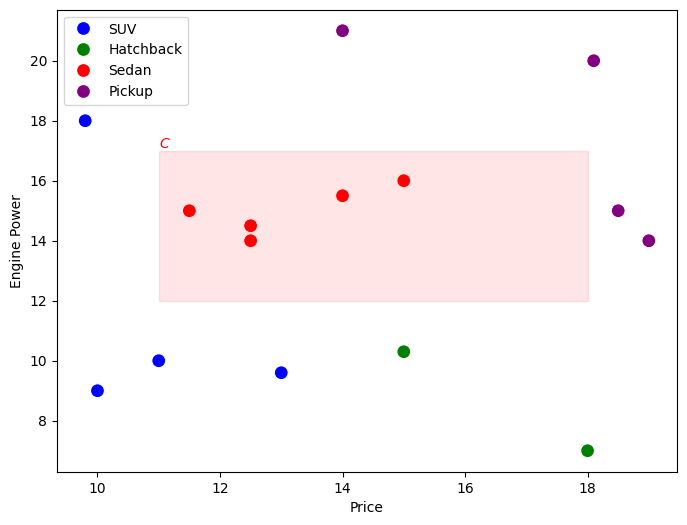

In [16]:
data = {
    "Price": [10, 11, 13, 15, 18, 9.8, 11.5, 12.5, 15, 12.5, 14, 14, 18.1, 18.5, 19],
    "Engine Power": [9, 10, 9.6, 10.3, 7, 18, 15, 14, 16, 14.5, 15.5, 21, 20, 15, 14],
     "Class": ["SUV", "SUV", "SUV", "H", "H", "SUV", "S", "S", "S", "S", "S", "O", "O", "O", "O"]
}
df = pd.DataFrame(data)
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=data, x="Price", y="Engine Power", hue="Class",
                palette=['blue', 'green', 'red', 'purple'], s=100)
handles, labels  =  ax.get_legend_handles_labels()
ax.legend(handles, ['SUV', 'Hatchback', 'Sedan', 'Pickup'])
ax.add_patch(
    plt.Rectangle((11, 12), 7, 5,   # Alto
        fill=True, alpha=0.1, color="red"
    )
)
ax.text(11, 17.1, "$C$", color="red")
plt.xlabel("Price")
plt.ylabel("Engine Power")
plt.show()

## **Vapnik-Chervonenkis (VC) Dimension**

> We **assume** that $\mathscr{H}$ includes $C$; that is, **there exists** $h \in \mathscr{H}$, such that $E(h|\textbf{X})$ is 0. Given a hypothesis class $\mathscr{H}$, it may be the case that **we cannot learn $C$**; that is, there exists no $h \in \mathscr{H}$ for which the error is 0. Thus, in any application, we need to make sure that $\mathscr{H}$ is flexible enough, or has enough **capacity**, to learn $C$.

> Let us say we have a dataset containing $N$ points. These $N$ points can **be labeled** in $2^N$ ways as positive and negative. Therefore, $2^N$ different **learning problems** can be defined by $N$ data points.


> If for **any** of these problems, we can find a hypothesis $h\in \mathscr{H}$ that separates the positive examples from the negative, then we say $\mathscr{H}$ **shatters** $N$ points.
> > That is, **any learning problem definable** by $N$ examples **can be learned** with no error by a hypothesis drawn from  $\mathscr{H}$.

> The **maximum number of points** that can **be shattered** by  $\mathscr{H}$ is called the **Vapnik-Chervonenkis (VC) dimension** of  $\mathscr{H}$, is denoted as $VC(\mathscr{H})$, and measures the **capacity** of $\mathscr{H}$.

### Example 1

>> Then $VC(\mathscr{H})$, when $\mathscr{H}$ is the hypothesis class of **axis-aligned rectangles** in two dimensions, is **four**. In calculating the
$VC$ dimension, it is enough that we find four points that can be shattered;
it is not necessary that we be able to shatter any four points in two dimensions. For example, four points placed on a line cannot be shattered
by rectangles. However, we cannot place five points in two dimensions
anywhere such that a rectangle can separate the positive and negative
examples for all possible labelings.

> **$VC$ dimension** may seem **pessimistic**. It tells us that using a rectangle
as our hypothesis class, we can learn only datasets containing four points
and not more. A learning algorithm that can learn datasets of four points
is not very useful.

> However, this is because the **$VC$ dimension** is **independent**
of the **probability distribution** from which instances are drawn. In real life, the world is smoothly changing, instances close by most of the time have the same labels, and we need not worry about all possible labelings. There are a lot of datasets containing many more data points than four that are learnable by our hypothesis class.

$VC$ dimension of some popular classifiers:

- **Linear classifiers** in $\mathbb{R}^d$,
$$ \mathscr{F} = \left\{f: f(\textbf{x}) = sign(\textbf{w}^T \textbf{x}), \ \textbf{w}\in \mathbb{R}^d\right\}$$
is $d$.

- **Affine classifiers**
$$ \mathscr{F}^{'} = \left\{f: f(\textbf{x}) = sign(\textbf{w}^T \textbf{x}+w_0), \ \textbf{w}\in \mathbb{R}^d, \ w_0\in \mathbb{R}\right\}$$
is $d+1$

- The **$k$-Nearest neighbors algorithm** using $k=1$ is **infinite**

- **Support Vector Machines (SVM)** with **radial basis kernel (RBF)** have **infinite** $VC$ dimension.

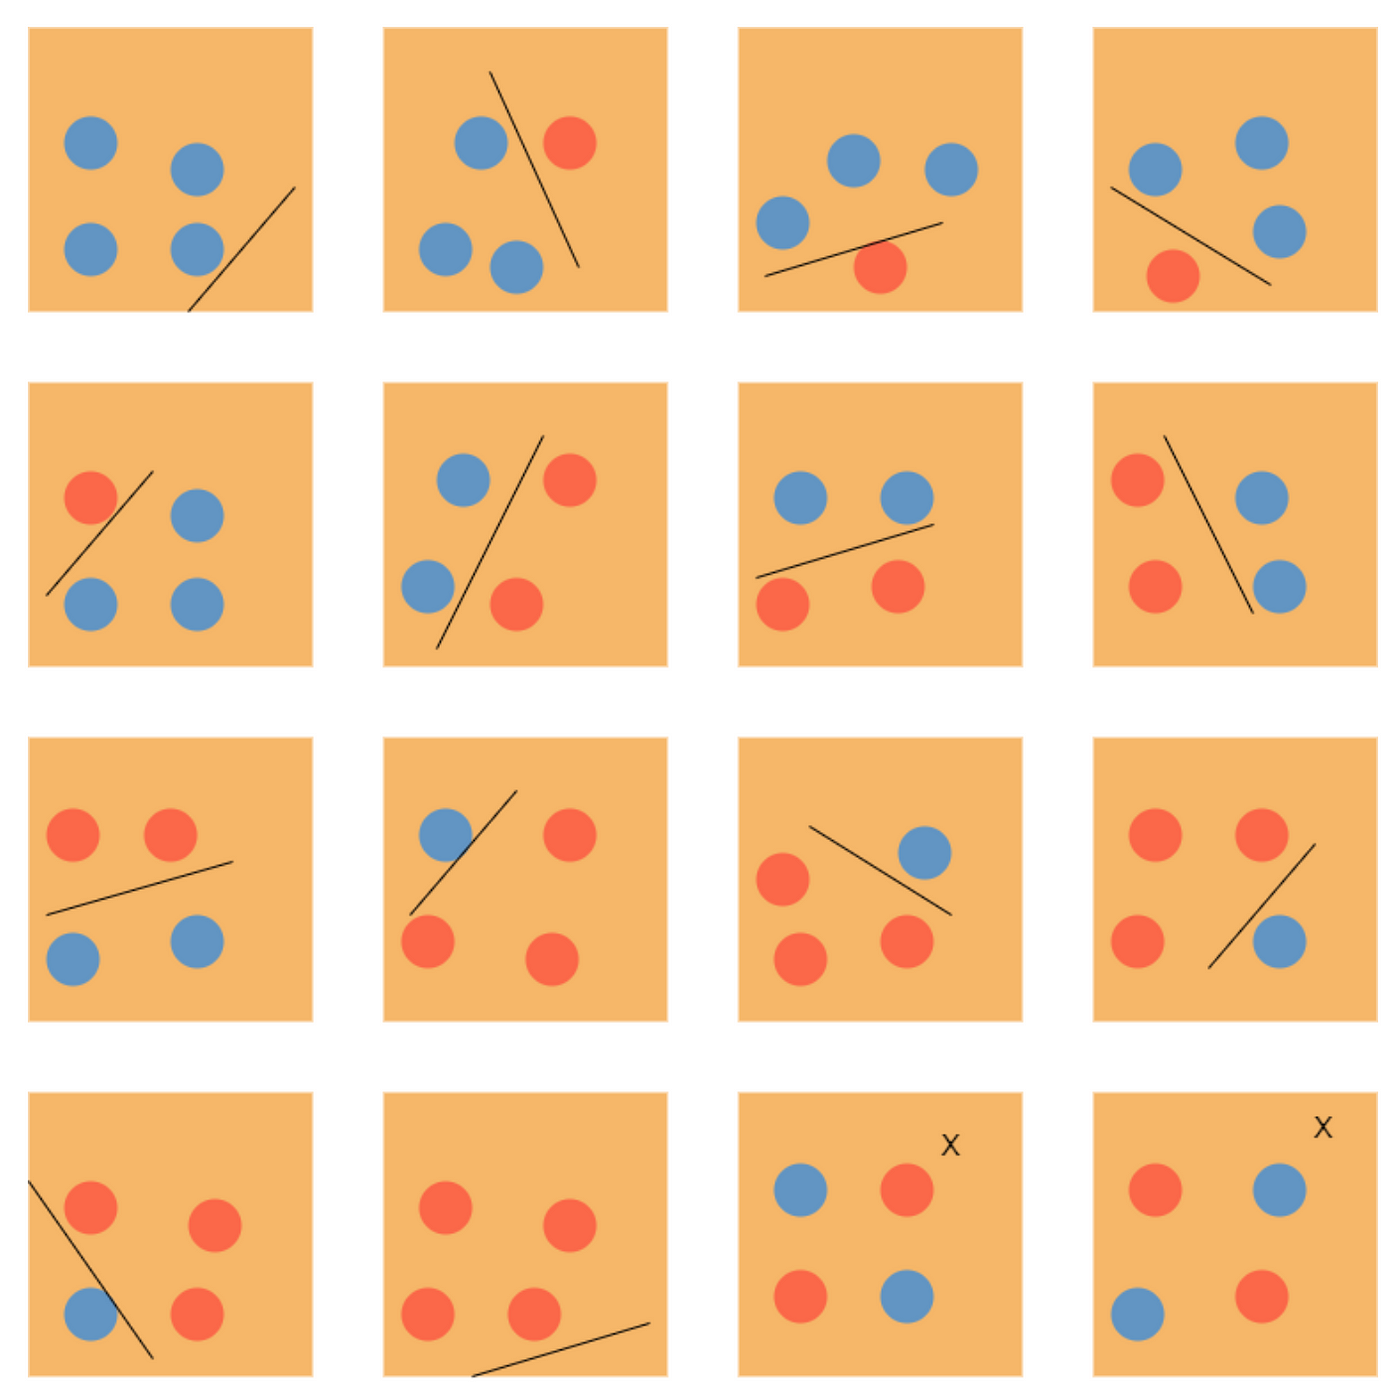

The $VC$ dimension is directly tied to a **model's complexity**:

- **Higher** $VC$ dimension: Indicates a more complex model capable of learning intricate patterns.
- **Lower** $VC$ Dimension: Suggests a simpler model with limited learning capacity.

Why is $VC$ dimension important?
 - **Generalization**: Models with too high a $VC$ dimension **may overfit** (perform well on training data but poorly on unseen data).

- **Simplicity**: A model with a lower $VC$ dimension **may underfit** (fail to capture the patterns in data).

## **Noise**

> **Noise** is any **unwanted anomaly** in the data. Due to noise, the class
may be more difficult to learn and zero error may be infeasible with a simple hypothesis class.

There are several interpretations of noise:
- There may be **imprecision in recording the input attributes**, which may
shift the data points in the input space.
- There may be **errors in labeling** the data points, which may relabel positive instances as negative and vice versa. This is sometimes called
**teacher noise**.
- There may be **additional attributes**, which we have not taken into account,
that affect the label of an instance. Such attributes may be hidden or latent in that they may be **unobservable**. The effect of these neglected attributes is thus modeled as a random component and is included in noise.

## **Model Selection**

> Each **hypothesis class** $\mathscr{H}$ has a certain **capacity** and can **learn** only certain functions. The class of functions that can be learned can be extended by using a hypothesis class with **larger capacity**, containing **more complex hypotheses**.
> >For example, the hypothesis class that is a union of two rectangles has higher capacity, but its hypotheses are more complex.

> Thus **learning** is not possible without **inductive bias**, and now the question is how to choose the right bias. This is called **model selection**, which is choosing between possible $\mathscr{H}$.

> In answering this question, we should
remember that the **aim** of machine learning is rarely to replicate the training data but the **prediction for new cases**.

> That is we would like to be able to generate the right output for an input instance outside the training set, one for which the correct output is not given in the training set. How well a model trained on the training set predicts the right output for new generalization instances is called **generalization**.

> For best generalization, we should **match** the **complexity** of the **hypothesis
class** $\mathscr{H}$ with the **complexity** of the **function underlying** the data.



>> If $\mathcal{H}$ is **less complex** than the function, we have **underfitting**. In such a case, as we increase the complexity, the training error decreases.

>> If we have $\mathcal{H}$ that is **too complex**, the data is not enough to constrain it and we may end up with a bad hypothesis, $h$. This is called **overfitting**. In such a case, having more training data helps but only up to a certain point.
>>> ***Given** a **training set** and **hypothesis set**, we can find $h\in \mathcal{H}$ that has the **minimum training error** but if $\mathcal{H}$ is not chosen well, no matter which $h$ we pick, we will not have
good generalization.*

> In all **learning algorithms** that are trained from example data,
there is a trade-off between three factors:
> - The **complexity of the hypothesis** we fit to data, namely, the **capacity**
of the hypothesis class.
> - The amount of **training data**.
> - The **generalization error** on new examples.

>>> *As the amount of training data increases, the generalization error decreases.*

>>> *As the complexity of the model class $\mathscr{H}$ increases, the generalization error decreases first and then starts to increase.*

> We can **measure** the **generalization ability** of a hypothesis, namely, the
**quality** of its **inductive bias**, if we have **access to data outside** the training set.

>  We **simulate** this by **dividing the training set** we have into two parts.
> * We use one part for **training** (i.e., to **fit a hypothesis**).
> * And the remaining part is called the **validation set** and is used to **test** the **generalization ability**.

> That is, given a **set of possible hypothesis classes** $\mathscr{H}_i$, for each **we fit the best** $h_i \in \mathscr{H}_i$ on the training set. Then, assuming large enough training and validation sets, the **hypothesis that is the most accurate on the validation set** is the **best one** (the one that has the best inductive bias). This process is called **cross-validation**.

> Note that if we need **to report the error** to give an idea about the **expected error** of our **best model**, we should **not use the validation error**.
We have used the **validation set to choose the best model**, and it has effectively become a part of the training set. We need a **third set**, a **test set**, containing examples not used in training or validation

## **Learning theory**

> **Machine learning** works from data.
> * In **supervised learning**, the machine is given both input data and **output labels**, from which it produces a model that can predict the label for any input.
> * In **unsupervised learning**, the machine is only given a set of input data from which it should extract knowledge.

### **Input data**

>We denote an input by $\textbf{x}$  and assume that all inputs are taken from **a set of possible inputs**, known as the **input space** $\mathcal{X}$

>In this course, we assume that the inputs are **real $d$-dimensional vectors**, i.e.,
$$\textbf{x}\in \mathcal{X} \subseteq \mathbb{R}^d$$
The word **features** will refer to the components $x$
$$x_j \in \mathbb{R}, \quad j=1,\ldots,d$$
of the input vectors
$$\textbf{x}=[x_1,\ldots,x_d]^T$$

>We will often consider sets of input vectors indexed by $i$ as $\textbf{x}_i$ or $\textbf{x}^i$. In this case, the $j$th component of $\textbf{x}_i$ is denoted $x_{ij}$.

>We will also consider inputs as **random vectors** $\textbf{X}$. In this context, $\textbf{x}$ refers to a **realization** of $\textbf{X}$.


### **Output labels**

> We denote a **label** by $y$ and assume that all labels for a given problem are taken from a **set of possible labels** $\mathcal{Y}$.

> We restrain ourselves to labels  $y$ that are either taken from a discrete set of integers, i.e., $\mathcal{Y}\subset \mathbb{Z}$, due we are dealing with a **classification problem**. (In the case of a **regression problem** $\mathcal{Y}\subseteq \mathbb{R}$).

> Most of the time, we will also consider labels as **random variables** $Y$  taking values in $\mathcal{Y}$ In this context, $y$ refers to a **realization** of $Y$.

### **Machine Learning**

> **Machine learning** is concerned with obtaining a **mapping** from the **input space** $\mathcal{X}$  to the **space of labels** $\mathcal{Y}$ from data in the case where the desired mapping cannot be explicited as a simple algorithm.

>> If the available data contains only examples from $\mathcal{X}$ , then this is **unsupervised learning**.

>> If for each datum from $\mathcal{X}$  the corresponding label in $\mathcal{Y}$  is also given, then this is **supervised learning**.

### **Predictive models**

In a **machine learning problem** characterized by a given input space and a given label space, a **predictive model** is a **function** that **assigns a label** to **every possible input**; and we call **predictions** the outputs of such a function.

>Given an input space $\mathcal{X}$ and a label space $\mathcal{Y}$, a **predictive model** is a function
$$f: \ \mathcal{X} \rightarrow \mathcal{Y}$$
that maps any input vector $\textbf{x}$ to a label $f(\textbf{x})$, called a **prediction**.



>Thus, **learning** can be formulated as the **search for a model** in the **space of all such functions**, denoted $\mathcal{Y}^{\mathcal{X}}$.

> However, this approach is usually not as directly implemented by learning algorithms for two major reasons:
> -  This approach might be **algorithmically intractable**, since it is very difficult for an algorithm to implement any function from the input space to the label space.
> - Even if we could implement all these functions, we would not be able to determine which one is the best one and the algorithm would be prone to **overfitting**.



> Instead of searching for a model in the set of all such function $\mathcal{Y}^{\mathcal{X}}$. most **learning algorithms** consider a **restricted model space**
$$\mathcal{F} \subset \mathcal{Y}^{\mathcal{X}}$$
also called a **function class**.

>> A popular example of such a function class is the set of all **linear classifiers** for two class problem. With input space $\mathcal{X}\subseteq \mathbb{R}^d$ and label space and label space $\mathcal{Y} = \{-1,1\}$, this can be represented as
$$\mathcal{F} = \left\{ f\in \mathcal{Y}^{\mathcal{X}}: \quad f(\textbf{x}) = \text{sign}(\textbf{w}^T\textbf{x} + w_0), \ \textbf{w}\in \mathbb{R}^d, \ w_0\in \mathbb{R}\right\}$$
Here, the **parameters** of the model that have **to be learned** from data are the components of the parameter vector $\textbf{w}$ and the bias $w_0$. This means that any pair $(\textbf{w}, w_0)$ uniquely **defines a model** $f$ in the function class $\mathcal{F}$.

>In a **supervised learning problem** with input space $\mathcal{X}$ and label space  $\mathcal{Y}$, a **learning algorithm** $\mathcal{A}$ is a mapping of the form
$$A: \ \left(\mathcal{F},\ \{(\textbf{x}_i,y_i)\}^N_{i=1}\right)\rightarrow f\in \mathcal{F}$$
where $\mathcal{F}$ is a **set of possible models**, $\{(\textbf{x}_i,\ y_i)\}^N_{i=1} \in (\mathcal{X}, \mathcal{Y})^N$  is a training set and $f$ is the returned predictive model.

In machine learning, we often encounter **parameterized function classes** for which the class of functions itself is defined up to the value of some parameters. A typical example is the class of polynomials parametrized by the degree of the polynomials.

In order to distinguish between the **parameters of the model** and the **parameters of the model class**, we call the latter **hyperparameters**.

The distinction between parameters and hyperparameters is of primary importance in order to understand the overall learning procedure. Indeed, while the values of the **parameters** are **automatically determined** by the **learning algorithm**, the **hyperparameters** must be **tuned by the user**.

> Some learning algorithms have one or more parameters that have to **be tuned by the user**. To differentiate these from the model parameters that **are learned** when applying the algorithm, we call the parameters of an algorithm its **hyperparameters**. In this case, the mapping takes the form
$$A: \ \left(\mathcal{F},\ \{(x_i,y_i)\}^N_{i=1},\ \gamma\right)\rightarrow f\in \mathcal{F}$$
for a generic (and possibly multidimensional) **hyperparameter** $\gamma$.



## **The risk and the loss function**

> In supervised learning, a **loss function** $$\mathcal{l}: \mathcal{Y}\times \mathcal{Y}\rightarrow \mathbb{R}^{+}\cup\{0\}$$
computes a **pointwise measure** $\mathcal{l}(y,\hat{y})$ of the **error** between a **label** $y$  and its **estimate** $\hat{y}$.

> For all $(y,\hat{y})\in \mathcal{Y}^2$, a **loss function** satisfies
$$\mathcal{l}(y,\hat{y})\geq 0$$
$$\hat{y}=y \quad \Rightarrow  \quad l(y, \hat{y})=0$$

The **risk** of a learning machine or model is the **amount** of **prediction error** that can be **expected** when using that model. The main goal in supervised learning is to **minimize this risk** in order to obtain the **most accurate model**.

In the sentence above, the "amount of error" is measured via a loss function.

> Given a loss function $\mathcal{l}$, the **risk** of a model $f$ is defined as the **expectation of the loss function** applied to the **output** of the model:
$$R(f)=\mathbb{E}_{\textbf{X},Y}\left[\mathcal{l}(Y, f(\textbf{X}))\right]$$}

> Using the **law of total expectation**, another convenient formulation involves the **conditional expectation** of $Y$ give $\textbf{X}$:
$$R(f)=\mathbb{E}_{\textbf{X}}\mathbb{E}_{Y|\textbf{X}=\textbf{x}}\left[\mathcal{l}(Y, f(\textbf{X})|\textbf{X}=\textbf{x})\right]$$


The **risk** is not a quantity that can be computed exactly, since it measures the quality of predictions of unknown phenomena, and in practice **must be estimated**.

### **Estimating the risk with a test sample**

The most simple estimate of the risk is the **test error**.  It is the **average loss** computed on an **independent and identically distributed (i.i.d.)** data sample, called the **test sample**.

If the **test sample** is **not independent** of the **training sample**, the test error cannot be considered as an **estimate** of the **risk**.

> The **risk** is defined as the expectation of the loss function and thus cannot be computed without knowledge of the **true data distribution**.

> The **test error** is a **simple estimate** of the **risk** that can be computed from data. Assume that we have access to both a training sample
$$D={(\textbf{X}_i,Y_i)}^N_{i=1}$$
and a test sample
$$D_{test}={(\textbf{X}_i^{'},Y_i^{'})}^{N_t}_{i=1}$$
of $N$ and $N_t$ **i.i.d. copies** of $(\textbf{X},Y)$.

> Note that this also implies the independence of $D$
 and $D_{test}$.

> The procedure is as follows: we train a model $f$  on the training sample and then **estimate its risk** from the test sample by computing the **test error**
$$R_{test}(f)=\frac{1}{N_t}\sum_{i=1} \mathcal{l}\left(Y_i^{'}, \ f(\textbf{X}_i^{'})\right)$$
The **law of large numbers** tells us that this **estimate converges** as $N_t$ tends towards infinity to the expectation of the loss function, i.e., to the **risk of $f$**.

### **Estimation versus approximation error**

* The **estimation error** is the error implied by the fact that the algorithm works with a **finite training set** that only **partially reflects** the **true distribution** of the data. By considering that the **training set** is **obtained by randomly sampling** the true distribution, this also incurs a certain **variability** in the resulting model.

* The **approximation error** is the error implied by the **choice of function class** and is defined as the **difference** in risk obtained by the best model within the function class and the optimal model.

> Given a supervised learning problem with a fixed distribution of the random pair of inputs $\textbf{X}\in \mathcal{X}$ and labels $Y\in \mathcal{Y}$, one can define the **optimal target model** $t$ as the one with minimal risk
$$R^{∗}=R(t)=\inf_{f:\mathcal{X}\rightarrow \mathcal{Y}} R(f)$$
In this definition, the minimum is considered over **all possible functions** from the input space $\mathcal{X}$  to the label space $\mathcal{Y}$

> Another important model when considering algorithms working with a restricted function class $\mathcal{F}$, is the **best model within the class**:
$$f^{∗}=\arg\min_{f∈\mathcal{F}} R(f)$$

> With these definitions, the excess in error of a model $f$
 can be decomposed as
$$R(f)−R^{∗}=[R(f)−R(f^{∗})]+[R(f^{*})-R^{*}]$$
where the **estimation error** (first term) reflects the inability of the learning algorithm to find the best model $f^{*}$ in the class $\mathcal{F}$, while the **approximation error** (second term) is induced by the limited capacity of the chosen function class $\mathcal{F}$.

## **Regularization**

**Regularization** is a versatile approach to the problem of **overfitting**, which can be seen as a **modification of empirical risk minimization** with control of the **model complexity**.

In this approach, we minimize a trade-off between the training error and a regularization term which penalizes complex models.

**Regularized learning** in a function class $\mathcal{F}$ can be posed as the **functional optimization problem**
$$min_{f\in \mathcal{F}} R_{emp}(f)+\lambda \Omega(f)$$
where $R_{emp}(f)$ is the **empirical risk** of $f$
$$R_{emp}(f)=\sum_{i=1}^N \mathcal{l}(y_i,f(x_i))$$
using a loss function $\mathcal{l}$, $\Omega:\mathcal{F}\rightarrow \mathbb{R}^+ \cup \{0\}$ is a **regularizer** which penalizes too complex functions $f$, and $\lambda>0$  is a hyperparameter tuning the trade-off between the fit to the training data and the regularization.


## **References**

- Alpaydin, E. (2010) *Introduction to Machine Learning*, 2nd ed., The MIT Press.

- Lauer, F. (2014) [*An Interactive Journey into Machine Learning*](https://mlweb.loria.fr/book/en/machinelearning.html)